# Week 1: Auditing algorithmic fairness with ACSIncome dataset

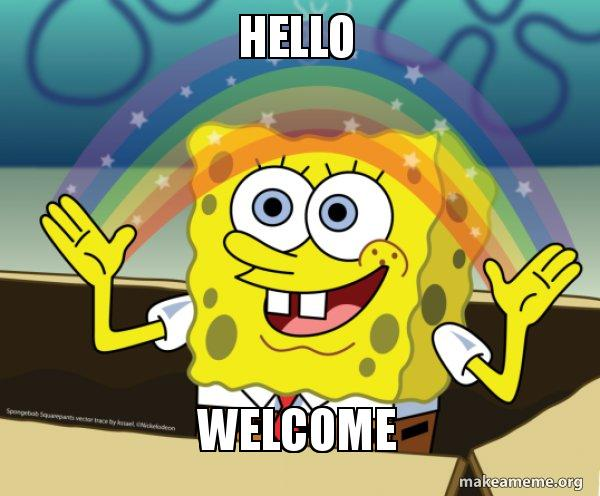

This guided notebook introduces a complete validation vocabulary before any mitigation is attempted.

**Learning goals**

1. Separate a target label, a prediction, and a decision.
2. Validate performance and group fairness.
3. Connect independence, separation, sufficiency, and calibration to their assumptions.


**Task**

The task predicts whether annual income exceeds USD 50,000 using 2018 ACS data. `SEX` is the binary coding available in this survey extract. It is not a complete measurement of gender identity.

In [16]:
# pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)
from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

## 1. Load and document the data

Before modelling, answer:

- What population is represented?
- What is the prediction target and who constructed it?
- Which variables are measurements, proxies, or administratively defined categories?
- Have a look at dataset description for code names ('columns') and their description - https://fairlearn.org/main/user_guide/datasets/acs_income.html

In [ ]:
source = ACSDataSource(survey_year="2018", horizon="1-Year", survey="person")
acs = source.get_data(states=[STATE], download=True)
X_all, y_all, race_codes = ACSIncome.df_to_pandas(acs)

X_all = X_all.reset_index(drop=True)
y_reference = y_all.squeeze().astype(int).reset_index(drop=True)
race_codes = race_codes.squeeze().reset_index(drop=True)
sex_group = X_all["SEX"].map({1: "Male", 2: "Female"}).fillna("Unknown")
race_names = {
    1: "White", 2: "Black", 3: "American Indian", 4: "Alaska Native",
    5: "AIAN specified/other", 6: "Asian", 7: "Pacific Islander",
    8: "Other race", 9: "Two or more races",
}
race_group = race_codes.map(race_names).fillna("Unknown")

strata = y_reference.astype(str) + "_" + sex_group.astype(str)
if len(X_all) > MAX_SAMPLES:
    keep, _ = train_test_split(
        np.arange(len(X_all)), train_size=MAX_SAMPLES,
        random_state=RANDOM_STATE, stratify=strata,
    )
    X_all = X_all.iloc[keep].reset_index(drop=True)
    y_reference = y_reference.iloc[keep].reset_index(drop=True)
    sex_group = sex_group.iloc[keep].reset_index(drop=True)
    race_group = race_group.iloc[keep].reset_index(drop=True)

display(X_all.head())
display(pd.crosstab(sex_group, y_reference, normalize="index").rename(columns={0:"income<=50k",1:"income>50k"}))
print("Rows:", len(X_all), "Features:", X_all.shape[1])

### Label notation used throughout the course

| Symbol | Meaning | Use |
|---|---|---|
| $Y^{ref}$ | Best available reference outcome | Final validation and test audit |
| $Y^{obs}$ | Label available to us; in real-life | Training and realistic validation |
| $S=P(\hat Y=1)$ | Model score | Ranking and calibration |
| $\hat Y$ | Thresholded or postprocessed decision | Decision metrics |

In Week 1, $Y^{obs}=Y^{ref}$. Later weeks deliberately separate them. “Reference” is more accurate than “ground truth”: real labels can still be incomplete or contestable.

In [ ]:
idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + sex_group.astype(str)
train_idx, temp_idx = train_test_split(idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(sex_group, z) for z in (train_idx, val_idx, test_idx)]
R_train, R_val, R_test = [take(race_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    "female_fraction": [(A_train=="Female").mean(), (A_val=="Female").mean(), (A_test=="Female").mean()],
}))

## 2. Fit a transparent baseline

We retain `SEX` and `RAC1P` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [ ]:
NUMERIC = ["AGEP", "WKHP"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Overall utility | Accuracy, balanced accuracy, AUROC, log loss, Brier | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |
| Calibration | Reliability, ECE, Brier | Does score $p$ correspond to about $p$ outcome frequency? | Does not imply equal errors or equal selection |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

In [ ]:
# TODO 

def false_positive_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return TODO if TODO else np.nan

def true_negative_rate_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return TODO if TODO else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return TODO if TODO else np.nan

metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)
print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

fairness_summary = pd.Series({
    "demographic_parity_difference": demographic_parity_difference(
        y_val, val_pred, sensitive_features=A_val),
    "demographic_parity_ratio": demographic_parity_ratio(
        y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_difference": equalized_odds_difference(
        y_val, val_pred, sensitive_features=A_val),
    "equalized_odds_ratio": equalized_odds_ratio(
        y_val, val_pred, sensitive_features=A_val),
})
display(fairness_summary)

In [ ]:
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score),
    "Brier": brier_score_loss(y_val, val_score),
})
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m]),
        "Brier": brier_score_loss(y_val[m], val_score[m]),
    })
display(pd.DataFrame(prob_rows).set_index("group"))

### Interpretation checkpoint

Write four sentences:

1. Which group has the higher selection rate, and by how much?
2. Which group has the higher FPR and which has the higher TPR?
3. Does the direction of the PPV gap match the direction of the selection-rate gap?
4. What can you **not** conclude from these numbers alone?

In [ ]:
interpretation = ""
print(interpretation)

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

In [ ]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

## 5. Calibration by group

Calibration is evaluated against a specified label. State that label every time. Here it is the Week 1 reference label.

In [ ]:
def calibration_table(y, score, group, bins=10):
    frame = pd.DataFrame({"y": np.asarray(y), "score": score, "group": np.asarray(group)})
    frame["bin"] = pd.cut(frame["score"], bins=np.linspace(0,1,bins+1), include_lowest=True)
    return (frame.groupby(["group","bin"], observed=False)
            .agg(n=("y","size"), mean_score=("score","mean"), outcome_rate=("y","mean"))
            .reset_index())

cal = calibration_table(y_val, val_score, A_val)
display(cal)
for g, part in cal[cal.n >= 25].groupby("group"):
    plt.plot(part.mean_score, part.outcome_rate, marker="o", label=g)
plt.plot([0,1],[0,1], "k--", label="ideal")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed reference outcome rate")
plt.legend(); plt.grid(True); plt.show()

## 6. Cleanlab introduction

Cleanlab ranks examples whose labels are inconsistent with model-predicted class probabilities. It does **not** prove that a label is wrong. Predictions must be out-of-sample. In-sample probabilities can conceal issues through overfitting.

In [ ]:
from cleanlab.filter import find_label_issues

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_prob = cross_val_predict(
    make_model(X_train[FEATURES]), X_train[FEATURES], y_train,
    cv=cv, method="predict_proba", n_jobs=-1,
)
ranked_issue_idx = find_label_issues(
    labels=y_train.to_numpy(), pred_probs=oof_prob,
    return_indices_ranked_by="self_confidence",
)
issue_preview = X_train.iloc[ranked_issue_idx[:20]].copy()
issue_preview["observed_label"] = y_train.iloc[ranked_issue_idx[:20]].to_numpy()
issue_preview["p_class_1_oof"] = oof_prob[ranked_issue_idx[:20], 1]
display(issue_preview)
print("Flagged examples:", len(ranked_issue_idx))

### Cleanlab interpretation checkpoint

- Why does disagreement with the model not prove a label error?
- How can a misspecified model create false alarms?
- Why might real group differences or minority patterns be over-flagged?
- What additional evidence would you seek before changing a label?

## 7. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [ ]:
# TODO 1: fit a second model after removing SEX and RAC1P from predictive features.
# Retain A_val and R_val for auditing.
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["SEX", "RAC1P"]]

# model_without_a = ...
# score_without_a = ...
# pred_without_a = ...

In [ ]:
# Optional

# TODO 2: create an intersectional sensitive feature such as SEX x RACE.
# Require a minimum group size before interpreting a result.
intersection = A_val.astype(str) + " | " + R_val.astype(str)
display(intersection.value_counts().head(15))

## Week 1 target - 

Write down a short validation memo containing:

1. Dataset and outcome documentation.
2. One table of overall and sex-disaggregated metrics.
3. One threshold-sweep figure and one calibration figure.
4. Comparison with and without sensitive attributes as model inputs.
5. Four Cleanlab limitations.
6. A justified recommendation for what to investigate next.

Instructions for final submission is at end of Week-3 notebook